# recount2 — C2CP Pathway Coverage vs Sample Size (multiplier=100, max.iter=1000)

**Environment:** `clamp-analyses`

Plots the C2CP pathway coverage and K results produced by `07_recount2_coverage_multiplier_imp_fixed.ipynb`.

Coverage = proportion of input C2CP pathways significantly associated with an LV (FDR < 0.05),
following the `GetPathwayCoverage` approach from the multi-plier paper (Taroni 2018).

Input: `output/recount2_multiplier_imp_fixed/c2cp_subsample_{N}_seed_{idx}/CLAMPfull_C2CP.rds`

## Libraries

In [29]:
library(dplyr)
library(ggplot2)
library(here)

source(here("config.R"))

## Configuration

In [30]:
FDR_CUTOFF   <- 0.05
output_dir   <- file.path(config$GENERAL$OUTPUT_DIR, "recount2_multiplier_imp_fixed")
sample_sizes <- c(500, 1000, 2000, 4000, 8000, 16000, 32000)
n_seeds      <- 3

# Load CLAMP_K values from the results summary produced by 07_ (if available)
summary_csv <- file.path(output_dir, "subsample_results_summary_multiplier_imp_fixed.csv")
if (file.exists(summary_csv)) {
    results_summary <- read.csv(summary_csv, stringsAsFactors = FALSE)
    message("Loaded results summary from: ", summary_csv)
} else {
    results_summary <- NULL
    message("Results summary not found — will read CLAMP_K.rds per run as fallback")
}

Loaded results summary from: /home/msubirana/Documents/pivlab/clamp-analyses/output/recount2_multiplier_imp_fixed/subsample_results_summary_multiplier_imp_fixed.csv



## Coverage function

In [31]:
# Adapted from GetPathwayCoverage (Taroni 2018 / multi-plier)
GetPathwayCoverage <- function(clamp.result, fdr.cutoff = 0.05) {
    summary.df     <- clamp.result$summary
    input.pathways <- colnames(clamp.result$C)
    num.lvs        <- ncol(clamp.result$U)

    sig.pathways <- unique(summary.df$pathway[which(summary.df$FDR < fdr.cutoff)])
    sig.lvs      <- unique(summary.df$LV[which(summary.df$FDR < fdr.cutoff)])

    list(
        pathway           = length(sig.pathways) / length(input.pathways),
        lv                = length(sig.lvs) / num.lvs,
        sig.pathway.by.lv = length(sig.pathways) / num.lvs
    )
}

## Collect results per run

In [32]:
rows <- list()

for (n_target in sample_sizes) {
    for (run_idx in seq_len(n_seeds)) {
        run_dir  <- file.path(output_dir,
                              paste0("c2cp_subsample_", n_target, "_seed_", run_idx))
        rds_path <- file.path(run_dir, "CLAMPfull_C2CP.rds")

        if (!file.exists(rds_path)) {
            message("Not found — skipping: c2cp_subsample_",
                    n_target, "_seed_", run_idx)
            next
        }

        # Look up CLAMP_K from summary table, fall back to per-run .rds
        if (!is.null(results_summary)) {
            row_match <- results_summary[
                results_summary$sample_size == n_target &
                results_summary$run         == run_idx, ]
            clamp_k <- if (nrow(row_match) == 1) row_match$CLAMP_K else NA_integer_
        } else {
            k_path  <- file.path(run_dir, "CLAMP_K.rds")
            clamp_k <- if (file.exists(k_path)) readRDS(k_path) else NA_integer_
        }

        model <- readRDS(rds_path)
        cov   <- GetPathwayCoverage(model, fdr.cutoff = FDR_CUTOFF)

        rows[[length(rows) + 1]] <- data.frame(
            sample_size      = n_target,
            n_samples        = ncol(model$B),
            run              = run_idx,
            pathway_coverage = cov$pathway,
            lv_coverage      = cov$lv,
            clamp_k          = clamp_k
        )
        message(sprintf("n=%6d  run=%d  pathway_cov=%.2f%%  K=%d",
                        n_target, run_idx,
                        cov$pathway * 100, clamp_k))
    }
}

results_df <- dplyr::bind_rows(rows) %>%
    dplyr::mutate(sample_size = factor(sample_size,
                                       levels = sort(unique(sample_size))))
print(results_df)

n=   500  run=1  pathway_cov=3.60%  K=30

n=   500  run=2  pathway_cov=4.46%  K=27

n=   500  run=3  pathway_cov=3.86%  K=30

n=  1000  run=1  pathway_cov=4.98%  K=48

n=  1000  run=2  pathway_cov=5.17%  K=49

n=  1000  run=3  pathway_cov=5.43%  K=49

n=  2000  run=1  pathway_cov=6.11%  K=68

n=  2000  run=2  pathway_cov=8.24%  K=91

n=  2000  run=3  pathway_cov=7.72%  K=108

n=  4000  run=1  pathway_cov=11.50%  K=187

n=  4000  run=2  pathway_cov=7.94%  K=105

n=  4000  run=3  pathway_cov=10.98%  K=156

n=  8000  run=1  pathway_cov=13.30%  K=254

n=  8000  run=2  pathway_cov=10.75%  K=208

n=  8000  run=3  pathway_cov=14.87%  K=334

n= 16000  run=1  pathway_cov=17.83%  K=715

n= 16000  run=2  pathway_cov=18.21%  K=514

n= 16000  run=3  pathway_cov=18.92%  K=797

n= 32000  run=1  pathway_cov=20.04%  K=875

n= 32000  run=2  pathway_cov=17.35%  K=911

n= 32000  run=3  pathway_cov=19.37%  K=946



   sample_size n_samples run pathway_coverage lv_coverage clamp_k
1          500       500   1       0.03596853   0.9000000      30
2          500       500   2       0.04458599   1.0000000      27
3          500       500   3       0.03859123   0.8333333      30
4         1000      1000   1       0.04983140   0.8541667      48
5         1000      1000   2       0.05170476   0.8367347      49
6         1000      1000   3       0.05432746   0.8367347      49
7         2000      2000   1       0.06107156   0.8823529      68
8         2000      2000   2       0.08242788   0.8461538      91
9         2000      2000   3       0.07718247   0.7685185     108
10        4000      4000   1       0.11502435   0.7005348     187
11        4000      4000   2       0.07943050   0.7619048     105
12        4000      4000   3       0.10977894   0.7884615     156
13        8000      8000   1       0.13300862   0.7519685     254
14        8000      8000   2       0.10753091   0.6538462     208
15        

## Pathway coverage

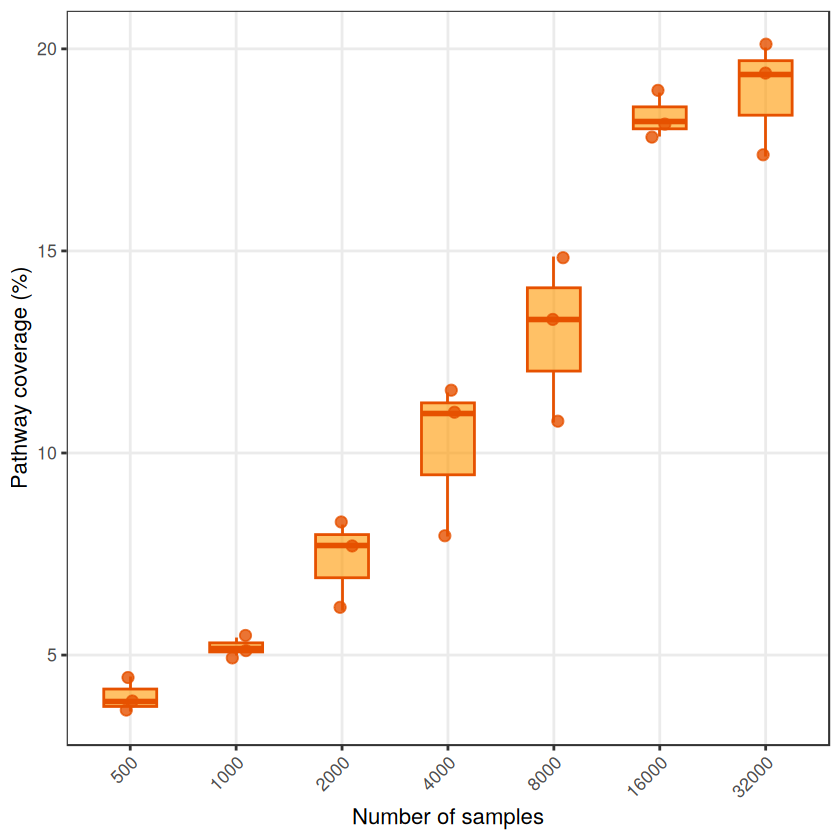

In [33]:
p_cov <- ggplot(results_df,
                aes(x = sample_size, y = pathway_coverage * 100)) +
    geom_boxplot(fill = "#FF9800", color = "#E65100",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#E65100", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x       = "Number of samples",
        y       = "Pathway coverage (%)",) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p_cov)

## K (number of components)

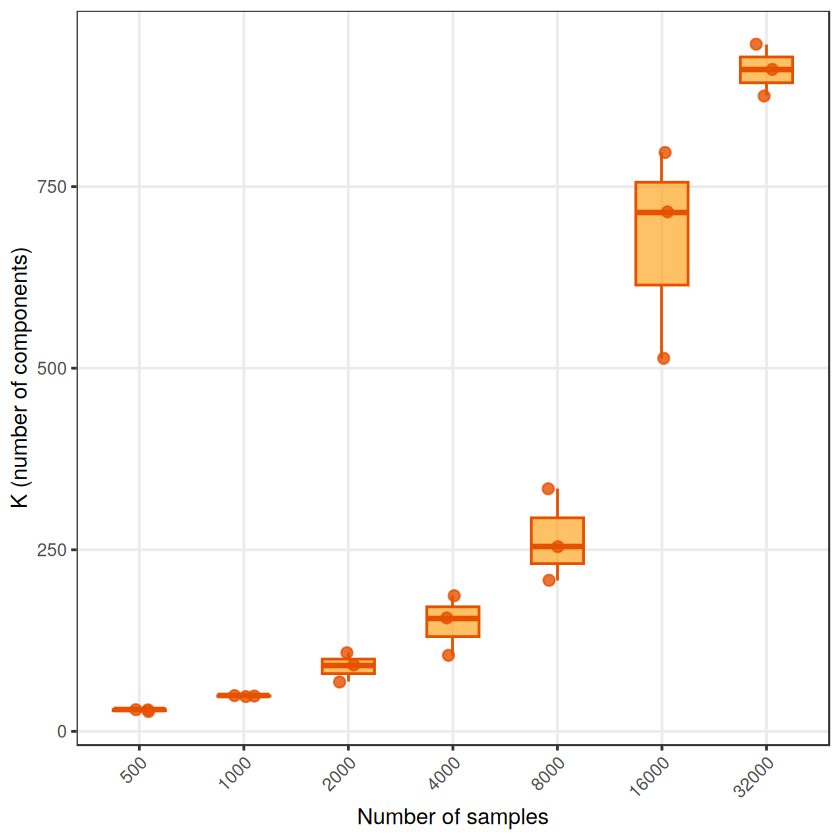

In [34]:
p_k <- ggplot(results_df,
              aes(x = sample_size, y = clamp_k)) +
    geom_boxplot(fill = "#FF9800", color = "#E65100",
                 alpha = 0.6, outlier.shape = NA, width = 0.5) +
    geom_jitter(color = "#E65100", width = 0.1, size = 2.5, alpha = 0.8) +
    labs(
        x = "Number of samples",
        y = "K (number of components)"
    ) +
    theme_bw(base_size = 13) +
    theme(
        axis.text.x      = element_text(angle = 45, hjust = 1),
        panel.grid.minor = element_blank()
    )

print(p_k)

## Summary table

In [35]:
results_df %>%
    dplyr::group_by(sample_size) %>%
    dplyr::summarise(
        median_cov = round(median(pathway_coverage) * 100, 2),
        min_cov    = round(min(pathway_coverage) * 100, 2),
        max_cov    = round(max(pathway_coverage) * 100, 2),
        median_k   = median(clamp_k, na.rm = TRUE),
        n          = dplyr::n(),
        .groups    = "drop"
    ) %>%
    dplyr::arrange(sample_size)

sample_size,median_cov,min_cov,max_cov,median_k,n
<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>
500,3.86,3.60,4.46,30,3
1000,5.17,4.98,5.43,49,3
2000,7.72,6.11,8.24,91,3
4000,10.98,7.94,11.50,156,3
8000,13.30,10.75,14.87,254,3
16000,18.21,17.83,18.92,715,3
32000,19.37,17.35,20.04,911,3
